In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as con
from scipy.special import erf, erfi
from numpy import sqrt, pi, exp
import scipy
from scipy.optimize import fsolve


# 23/03/2025

In [2]:
def speed(v):
    return sqrt(np.sum(v**2))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc
    

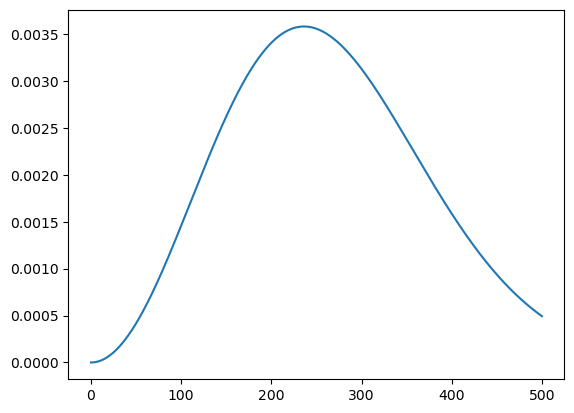

In [3]:
# example of single gaussian/stream

plt.clf()
v = np.linspace(0, 500, 10000)
sig = 167
f = speedDistGaussian(v, sig, 1)
plt.plot(v, f)

In [4]:
def streamN(v):
    sigg = 2.58
    sige = 5.6
    c_0 = 1.1
    f1 = exp(-0.5 * v**2 / sigg**2)
    f2 = c_0 * exp(- np.abs(v) / sige)
    return f1+f2

<Figure size 640x480 with 0 Axes>

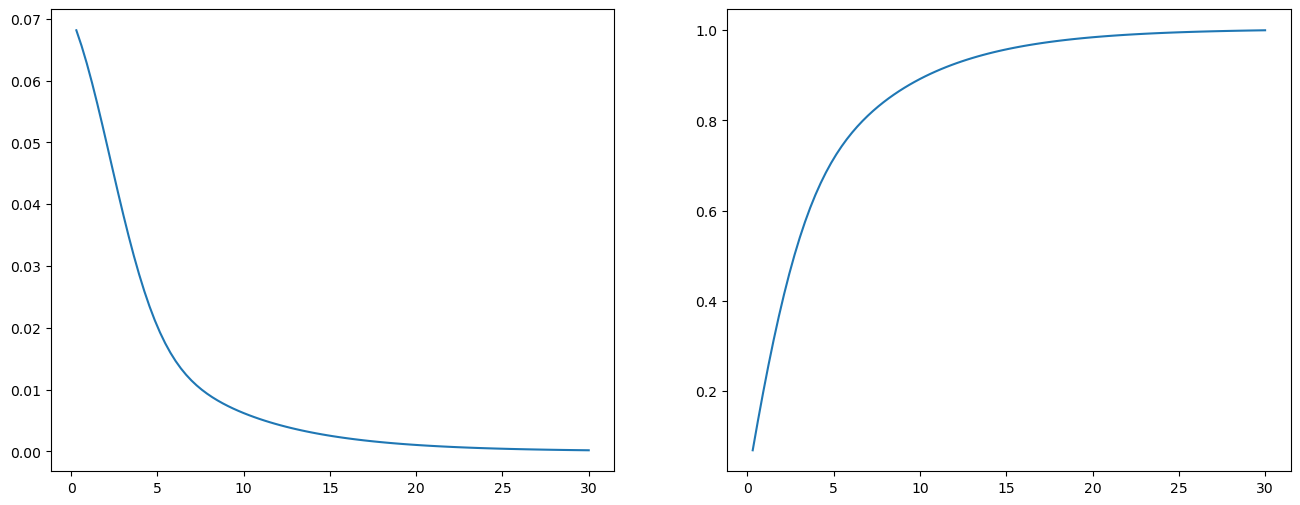

In [5]:
#from https://iopscience.iop.org/article/10.3847/1538-4357/ad7b35
#using random constant values for now
# this is just a placeholder to find a value for N_str, i didn't read thru the full paper
# the paper produces the plots below based on radial velocity?

v = np.linspace(0, 30, 100)[1:] # the paper goes from -20 to 20, \
    #however we don't care the direction only the speed of the stream
    # maybe need to change the maximum velocity??
y = streamN(v) / np.sum(streamN(v))
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, y)
ax[1].plot(v, y.cumsum())

v_str = np.column_stack((v, y))
#np.random.seed(0)
#v_str = np.random.choice(a=v, p=y, size = 1000)



In [6]:
np.random.seed(0)
v_strs = np.random.choice(a=v, p=y, size = 10000)
y = streamN(v_strs)
y = y / np.sum(y)
v_str = np.column_stack((v_strs, y))

In [7]:
v = np.linspace(0, 30, 1000)[1:]

f = []
sig = 0.005
for i in v_str:
    v_c = i[0]
    p = i[1]
    f.append(p* speedDistGaussian(v, sig, v_c))

f = np.array(f)

<Figure size 640x480 with 0 Axes>

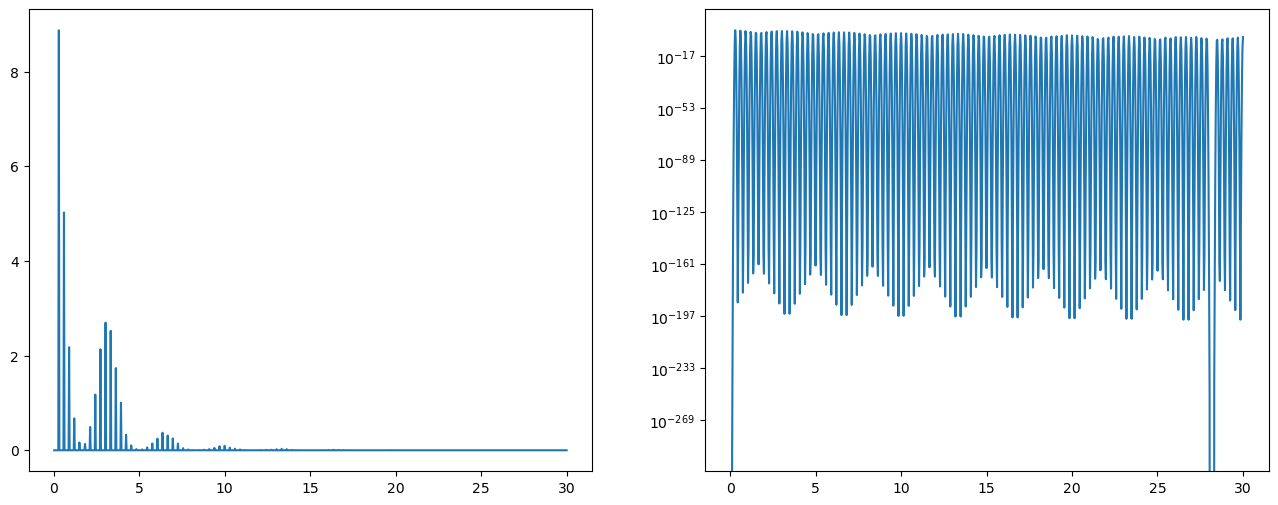

In [8]:
plt.clf()
plt.clf()
fig, ax = plt.subplots(1, 2, figsize=(16,6))
ax[0].plot(v, f.sum(axis=0))
ax[1].semilogy(v, f.sum(axis=0))

In [9]:
v_str[:, 0]

array([3.33333333, 5.15151515, 3.63636364, ..., 6.06060606, 0.3030303 ,
       7.27272727])

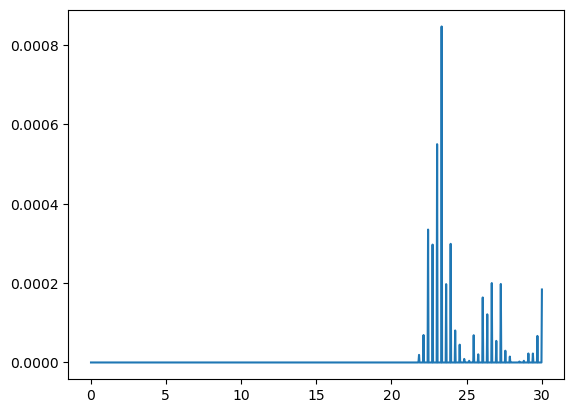

In [10]:
plt.clf()
plt.plot(v, f[np.argsort(v_str[:, 0])][::-1][:100].sum(axis=0))

In [11]:
np.argsort(v_str[:, 0])[::-1]

array([2836, 2749, 5081, ..., 4786, 4783, 8150])

In [12]:
f[np.argsort(v_str[:, 0])][::-1][:50].sum(axis=0)

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0

In [13]:
# random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
# look at fine gained structured for rho/M
# velocity of streams 
# phase mixing

# for traferring to signal use A.2 in fine grained
# quality factor q = w_0 / delta w = m_a / m_a / v^2

# 25th to 31st March
## Feedback:
- Better to sample stream velocities from the halo's gaussian distribution. Easy to do this, just use random.multivariate_normal, centred on (0, 0, 0), covariance is diagonal (dispersion of halo squared ~167)
- Each stream should have a different density as well. Specifically we use, f (ρ) = scipy.stats.skewnorm.pdf(log(rho),-2.10,loc=-11.37,scale=7.15)/rho, as shown in Ciaran's Fine-grained dark matter paper
- Look at phase mixing, it tells us about velocity of streams/ how the streams came to be (folds etc.) (optional for now)
- After making a proper model/distribution, look into extracting/transforming it into a signal (A.2. in fine grained.) quality factor q = w_0 / delta w = m_a / m_a / v^2


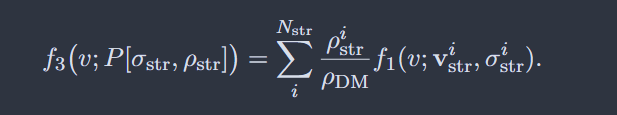

In [14]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [15]:
def fun(rho, str_num):
    return np.abs(scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho - str_num)

def get_density(str_num):
    # returns the optimum stream density to get 
    return scipy.optimize.minimize(fun, x0 = 2.04e-3, bounds = [(7.7e-8, np.inf)], args=[str_num]).x[0]

v_c = np.array([[218, -119, 21]]) # just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 1000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167]*3), num)
spd = speed(vel + v_c)

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([spd, rho])


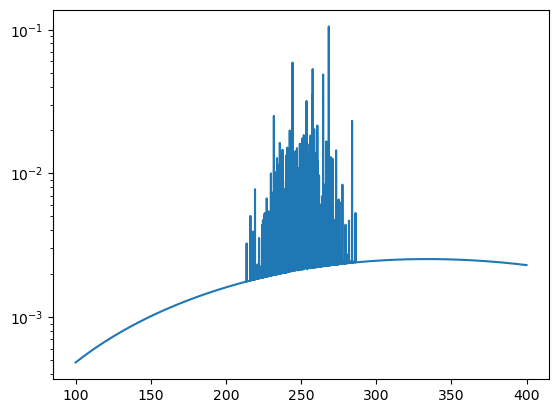

In [16]:
plt.clf()
deltas = []
sig = 0.01 # ask ciaran what do to about the dispersion velocities
v = np.linspace(100, 400, 5000)
for v_e, p in streams:
    gauss = p * speedDistGaussian(v, sig, v_e)
    deltas.append(gauss)

perturb = np.sum(deltas, axis = 0)
total = speedDistGaussian(v, 167, speed(v_c)) * (1 - np.sum(rho)) + perturb

plt.semilogy(v, total)

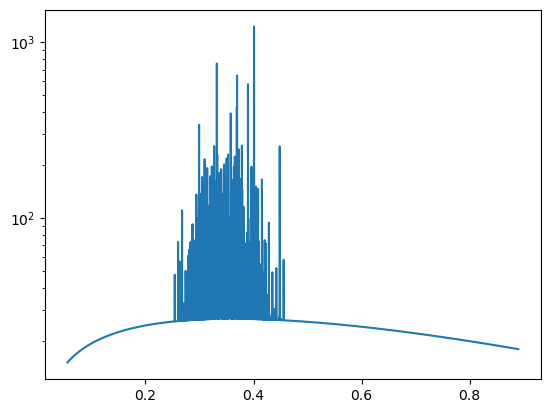

In [17]:
m_a = 1e-6 # in eV
lineshape = np.pi * total / (m_a *v) # T -> infty

w = (v*v/con.c / con.c *1e6 + 2)*m_a / 2
plt.clf()
plt.semilogy((w/m_a - 1) * 1e6, lineshape)

In [18]:
# CONVERT IT FOR LOCAL SUN

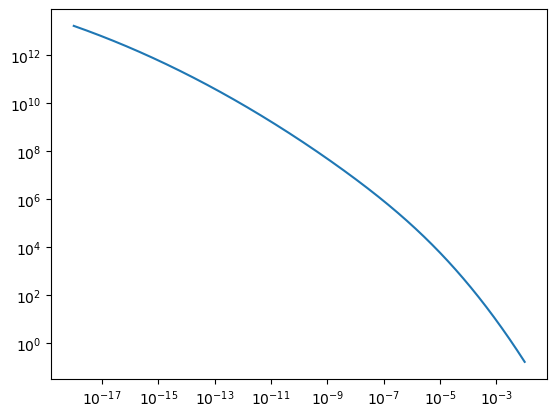

In [19]:
rho = np.logspace(-18, -2, 1000)
f = scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho
plt.clf()
plt.loglog(rho, f)

# 15th April -

In [20]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [21]:
v_c = np.array([12.9, 245.6, 7.78])# + np.array([100, -50 ,0 ])# just set it to 1 cause v_c = 0 breaks the function
# 8th march

num = 10000
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167**2]*3), num) 

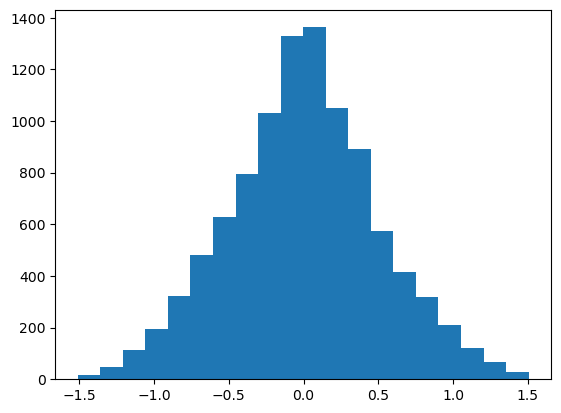

In [22]:
vel += v_c

cost = vel[:, 2] / speed(vel)
phi = np.arctan(vel[:, 1] / vel[:, 0])
omega = cost*phi
plt.hist(omega, 20)

vel -= v_c

# so this changes according to v_c, i.e. it centres around v_c

In [23]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

vel += v_c

def v_inf(v):
    r = np.array([v_c]) * np.array([[1, 0, 1]]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi

vel -= v_c

In [24]:

def func(v, vi):
    return (v_inf(v) - vi).T[:, 0]

vel += v_c

v = []
for vi in vel:
    root = fsolve(func, [25,25, 25], args=(vi,))
    v.append(root)
v = np.array(v)
vel -= v_c
v

/tmp/ipykernel_682/1116779107.py:10: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_682/2658855099.py:8: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [25,25, 25], args=(vi,))
/tmp/ipykernel_682/2658855099.py:8: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  root = fsolve(func, [25,25, 25], args=(vi,))


array([[ 306.00560584,  317.30422612,  170.10788287],
       [ 386.53222581,  559.07358593, -156.89559238],
       [ 170.03477948,  225.30300026,  -12.93264335],
       ...,
       [ 185.34148465,  268.06111639, -122.63482572],
       [ 112.36521957,  182.41416621,  -94.39248614],
       [-241.37887008,  409.86270089,  217.30557274]])

In [25]:
mask = np.floor(np.sum(v != [-25, 25, -25], axis = 1)/3).astype(bool)
v = v[mask]
mask.sum()

9360

(array([1.390e+02, 2.730e+02, 4.740e+02, 7.780e+02, 9.780e+02, 1.178e+03,
        1.243e+03, 1.154e+03, 9.730e+02, 7.860e+02, 5.620e+02, 3.510e+02,
        2.360e+02, 1.190e+02, 6.800e+01, 3.100e+01, 1.000e+01, 5.000e+00,
        1.000e+00, 1.000e+00]),
 array([ 42.13191922,  88.31209874, 134.49227825, 180.67245777,
        226.85263729, 273.03281681, 319.21299632, 365.39317584,
        411.57335536, 457.75353488, 503.9337144 , 550.11389391,
        596.29407343, 642.47425295, 688.65443247, 734.83461198,
        781.0147915 , 827.19497102, 873.37515054, 919.55533005,
        965.73550957]),
 <BarContainer object of 20 artists>)

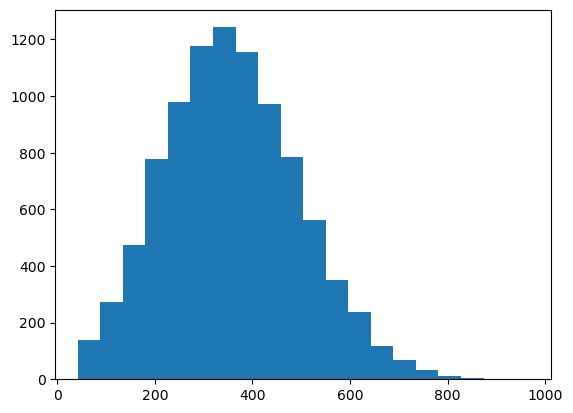

In [26]:
vh = [v[i] / speed(np.array([v[i]])) for i in range(len(v))]
vh = np.array(vh)
plt.hist(speed(v), 20)

(array([  12.,   45.,   94.,  180.,  281.,  435.,  636.,  757.,  992.,
        1176., 1413., 1001.,  800.,  513.,  354.,  282.,  190.,  129.,
          55.,   15.]),
 array([-1.55651003, -1.40259256, -1.24867509, -1.09475762, -0.94084015,
        -0.78692268, -0.63300521, -0.47908774, -0.32517027, -0.1712528 ,
        -0.01733533,  0.13658214,  0.29049961,  0.44441708,  0.59833455,
         0.75225202,  0.90616949,  1.06008697,  1.21400444,  1.36792191,
         1.52183938]),
 <BarContainer object of 20 artists>)

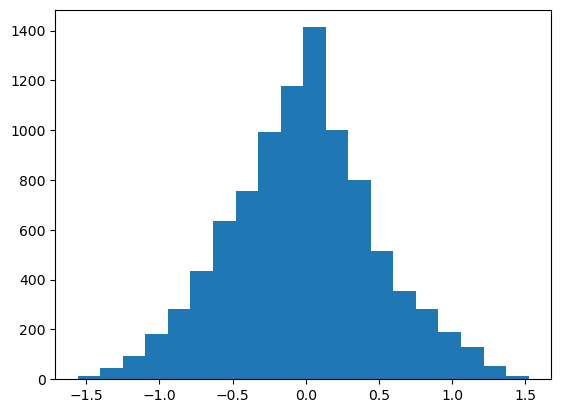

In [27]:
cost1 = v[:, 2] / speed(v)
phi1 = np.arctan(v[:, 1] / v[:, 0])
omega1 = cost1*phi1
plt.hist(omega1, 20)

array([  0.,  54.,  41.,  61.,  98., 139., 157., 213., 260., 327., 359.,
       384., 427., 465., 492., 524., 528., 512., 514., 472., 431., 412.,
       397., 344., 317., 274., 223., 178., 164., 130., 107., 101.,  57.,
        58.,  34.,  33.,  23.,  15.,  13.,   6.,   9.,   0.,   5.,   0.,
         0.,   1.,   0.,   0.,   1.])

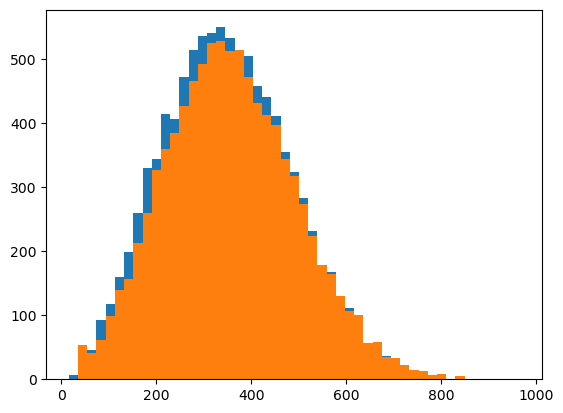

In [28]:
plt.clf()

dist_i = speed(vel + v_c) #omega
dist_f = speed(v) #omega1

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 50)
plt.hist(dist_i, bins)[0]
plt.hist(dist_f, bins)[0]

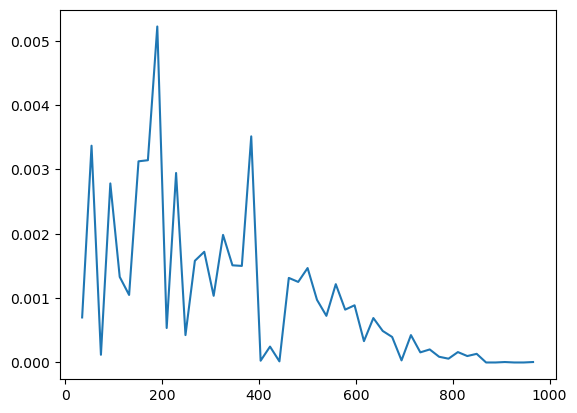

In [29]:
y = plt.hist(dist_i, bins)[0] * np.sum(mask)/10000 - plt.hist(dist_f, bins)[0]
plt.clf()
plt.plot(bins[1:], np.abs(y) / np.sum(mask))

array([  1.,   4.,  -6.,  -3.,  -4.,   3.,  -6.,   6.,   3.,   1.,   8.,
         1.,   2.,   9.,  -8.,   2.,  -3.,   5.,  13.,   5.,  22.,  12.,
        39.,  46.,  10.,  -6.,  51.,  39.,  42.,  19.,  67.,  42.,  37.,
        27.,  38.,  34.,  18.,  19.,  19.,  -2.,  29., -13.,   0.,   0.,
         3.,   3.,   7.,   4.,   1.])

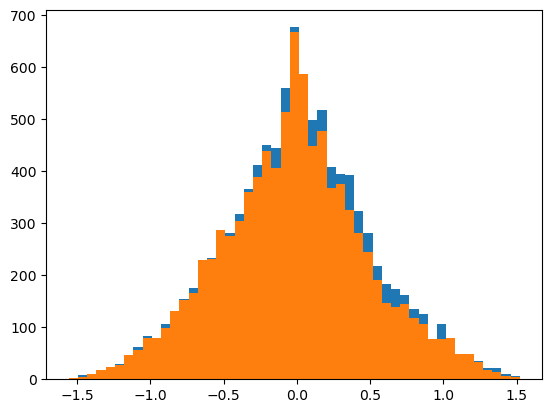

In [30]:
plt.clf()

dist_i = omega
dist_f = omega1

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 50)
plt.hist(dist_i, bins)[0] - plt.hist(dist_f, bins)[0]

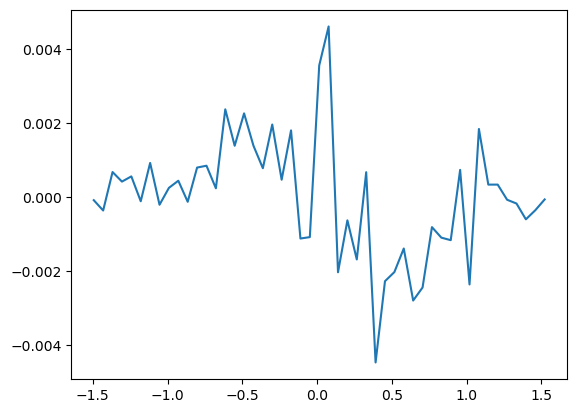

In [31]:
y = plt.hist(dist_i, bins)[0] * np.sum(mask)/10000 - plt.hist(dist_f, bins)[0]
plt.clf()
plt.plot(bins[1:], -y / np.sum(mask))

In [32]:
phi.shape

(10000,)

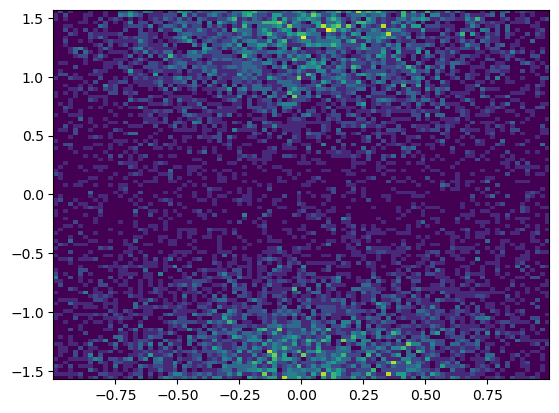

In [33]:
from matplotlib.colors import LogNorm, SymLogNorm

plt.clf()

bins1 = np.linspace(min(np.min(cost), np.min(cost1)), max(np.max(cost), np.max(cost1)), 100)
bins2 = np.linspace(min(np.min(phi), np.min(phi1)), max(np.max(phi), np.max(phi1)), 100)


vals = plt.hist2d(cost1, phi1, bins = 100)[0] - plt.hist2d(cost, phi, bins = 100)[0]


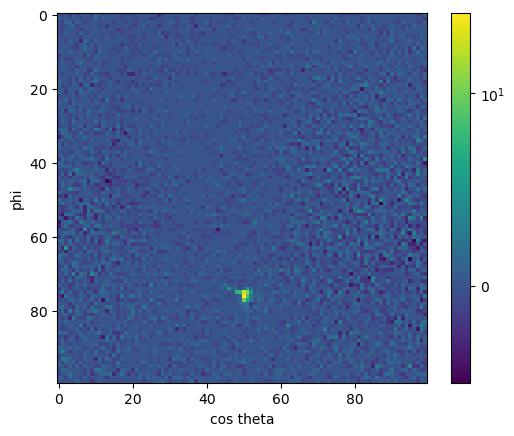

In [34]:
plt.clf()
plt.imshow(vals, norm = SymLogNorm(linthresh=10))
plt.xlabel("cos theta")
plt.ylabel("phi")
plt.colorbar()

In [35]:
bins[np.argmax(-y)], np.mean(omega)

(0.014076401619783852, 0.0007806766730814431)

In [36]:
np.mean(omega1)

-0.019903247256983683

In [37]:
# plot a 2d histogram of costheta, phi (difference between f_gf and f)
# use str vels i picked out to make a new distribution with stream densities and plot a 2d histogram of that
# keep the derivative of a delta function.

In [38]:
# Look at velocity distribution of a single stream and see if it gets gravitationally focused in a range of (-10 10) degrees from the sun

# 4th May

In [39]:
def speed(v):
    return sqrt(np.sum(v**2, axis = 1))

def Nesc_gaussian(sig, v_esc):
    # Got this from github.com/cajohare/DarkShards/blob/master/code/HaloFuncs.py
    # sig = 1d dispersion
    # v_esc = escape velocity
    return erf(v_esc/(sqrt(2)*sig)) - \
    sqrt(2.0/pi)*(v_esc/sig)*exp(-v_esc**2.0/(2.0*sig**2.0))

def fv_gaussian(v, sig, v_c, v_esc = 528.0):
    constants = 2 * pi * sig**2
    constants = 1 / (np.pow(constants, 3/2))
    
    N_esc = Nesc_gaussian(sig, v_esc)
    
    f = exp(-(speed(v - v_c)**2) / 2 / (sig**2)) / N_esc
    
    return constants * f

def speedDistGaussian(v, sig, v_c, v_esc= 528.0):
    constants = v / (sqrt(2*pi) * v_c * sig)
    
    # got this from ciaran's fine grained dark matter paper, is v_e supposed to be v_c?
    f1 = exp(- (v**2 + v_c**2 - 2*v*v_c) / (2 * sig**2))
    f2 = exp(- (v**2 + v_c**2 + 2*v*v_c) / (2 * sig**2))
    
    N_esc = Nesc_gaussian(sig, v_esc) # what is N_esc?
    #print(N_esc)
    
    return (f1 - f2) * constants / N_esc

In [40]:
import astropy.constants as acon

def grav(x):
    return - acon.G.value * 1e-9 * acon.M_sun.value / 149600000

def rotate(t):
    return np.array(([np.cos(t), 0, np.sin(t)],
              [0, 1, 0],
              [-np.sin(t), 0, np.cos(t)]))


def v_inf(v, t):
    r = np.array([rotate(t) @ v_c]) # in km
    d = np.sqrt(np.sum(v*v) + 2 * grav(r))

    vi = d * d * v \
        -  d * r / speed(r) * grav(r) \
        - d * v * (np.dot(v, r.T / speed(r)))
    
    vi = vi / (d*d - grav(r) - d * np.dot(v, r.T / speed(r)))
    
    return vi


In [41]:
sig = 0.1
num = 10000
v_c = np.array([12.9, 245.6, 7.78]) + np.array([20, 0, 0]) 
stream = np.random.multivariate_normal(v_c, np.diag([sig**2]*3), num) 

In [42]:
v_c

array([ 32.9 , 245.6 ,   7.78])

In [43]:
def func(v, vi , t):
    return (v_inf(v,t) - vi)[0]

v = []
t = np.deg2rad(10)
for vi in stream:
    root = fsolve(func, [25,25, 25], args=(vi,t))
    v.append(root)
v = np.array(v)

In [44]:
mask = np.floor(np.sum(v != [25, 25, 25], axis = 1)/3).astype(bool)
v = v[mask]
mask.sum()

10000

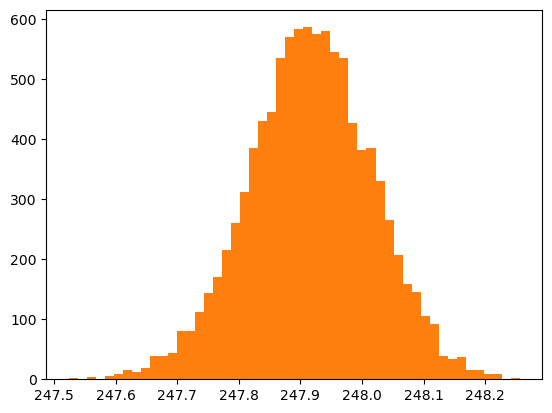

In [45]:
plt.hist(speed(stream), bins=50)

plt.hist(np.sqrt(speed(v)**2 + 2* grav(0)), bins=50)
print()

0.0

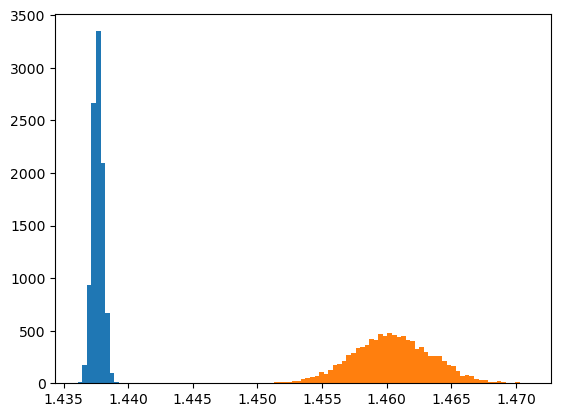

In [46]:
cost1 = v[:, 2] / speed(v)
phi1 = np.arctan(v[:, 1] / v[:, 0])
omega1 = cost1*phi1

cost = stream[:, 2] / speed(stream)
phi = np.arctan(stream[:, 1] / stream[:, 0])
omega = cost*phi

dist_i = phi
dist_f = phi1

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 100)
np.sum(plt.hist(dist_i, bins)[0]) - np.sum(plt.hist(dist_f, bins)[0])


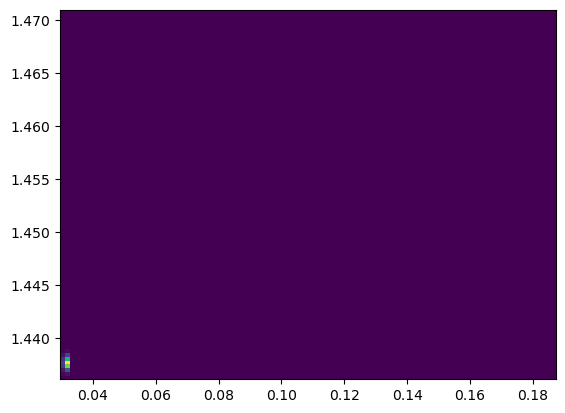

In [47]:
from matplotlib.colors import LogNorm, SymLogNorm

plt.clf()

bins1 = np.linspace(min(np.min(cost), np.min(cost1)), max(np.max(cost), np.max(cost1)), 100)
bins2 = np.linspace(min(np.min(phi), np.min(phi1)), max(np.max(phi), np.max(phi1)), 100)



vals = plt.hist2d(cost1, phi1, bins = [bins1, bins2])[0] - plt.hist2d(cost, phi, bins = [bins1, bins2])[0] * np.sum(mask)/num


<Figure size 640x480 with 0 Axes>

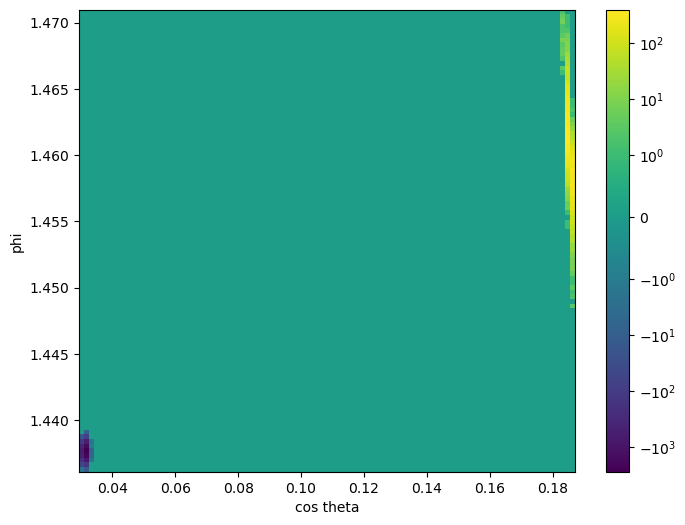

In [48]:
plt.clf()
plt.figure(figsize=(8, 6))
X = np.linspace(-1, 1, 100)
Y = np.linspace(0, np.pi * 2, 100)
plt.pcolormesh(bins1, bins2, vals.T, norm = SymLogNorm(linthresh=1))
plt.xlabel("cos theta")
plt.ylabel("phi")
plt.colorbar()

In [49]:
def fun(rho, str_num):
    return np.abs(scipy.stats.skewnorm.pdf(np.log(rho),-2.10,loc=-11.37,scale=7.15)/rho - str_num)

def get_density(str_num):
    # returns the optimum stream density to get 
    return scipy.optimize.minimize(fun, x0 = 2.04e-3, bounds = [(7.7e-8, np.inf)], args=[str_num]).x[0]

v_c = np.array([12.9, 245.6, 7.78])
# 8th march

num = 100
np.random.seed(0)
vel = np.random.multivariate_normal((0, 0, 0), np.diag([167**2]*3), num)
vel += v_c
#spd = speed(vel + v_c)

rho = []
for str_num in range(1, num+1):
    rho.append(get_density(str_num))

streams = np.column_stack([vel, rho])


In [50]:
num = 10000
sig = 0.1

particles = []
total_density = np.sum(rho)

for i in streams:
    part = np.random.multivariate_normal(i[0:3], np.diag([sig**2]*3), int(i[3]/total_density * num))
    particles.extend(part)

particles = np.array(particles)

In [51]:
def func(v, vi , t):
    return (v_inf(v,t) - vi)[0]

v = []
t = np.deg2rad(0)
for vi in particles:
    root = fsolve(func, [25,25, 25], args=(vi,t))
    v.append(root)
v = np.array(v)

/tmp/ipykernel_682/1863297748.py:14: RuntimeWarning: invalid value encountered in sqrt
  d = np.sqrt(np.sum(v*v) + 2 * grav(r))
/tmp/ipykernel_682/880521743.py:7: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(func, [25,25, 25], args=(vi,t))


0.0

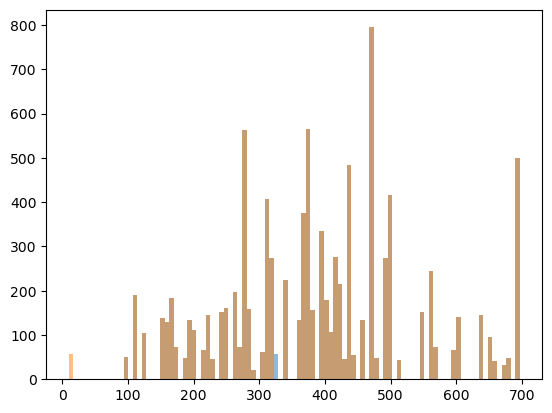

In [52]:
cost1 = v[:, 2] / speed(v)
phi1 = np.arctan(v[:, 1] / v[:, 0])
omega1 = cost1*phi1

cost = particles[:, 2] / speed(particles)
phi = np.arctan(particles[:, 1] / particles[:, 0])
omega = cost*phi

dist_i = speed(particles)
dist_f = np.sqrt(speed(v)**2 + 2* grav(0))

bins = np.linspace(min(np.min(dist_i), np.min(dist_f)), max(np.max(dist_i), np.max(dist_f)), 100)
np.sum(plt.hist(dist_i, bins, alpha=0.5)[0]) - np.sum(plt.hist(dist_f, bins, alpha = 0.5)[0])


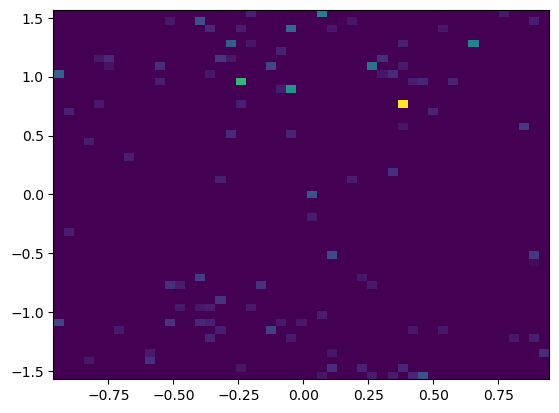

In [53]:
from matplotlib.colors import LogNorm, SymLogNorm

plt.clf()

bins1 = np.linspace(min(np.min(cost), np.min(cost1)), max(np.max(cost), np.max(cost1)), 50)
bins2 = np.linspace(min(np.min(phi), np.min(phi1)), max(np.max(phi), np.max(phi1)), 50)

vals = plt.hist2d(cost1, phi1, bins = [bins1, bins2])[0] - plt.hist2d(cost, phi, bins = [bins1, bins2])[0]


<Figure size 640x480 with 0 Axes>

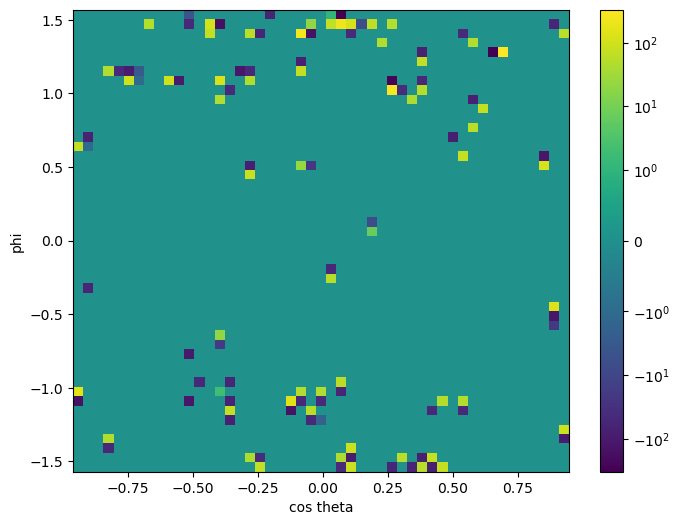

In [54]:
plt.clf() 
plt.figure(figsize=(8, 6))
X = np.linspace(-1, 1, 100)
Y = np.linspace(0, np.pi * 2, 100)
plt.pcolormesh(bins1, bins2, vals.T, norm = SymLogNorm(linthresh=1))
plt.xlabel("cos theta")
plt.ylabel("phi")
plt.colorbar()

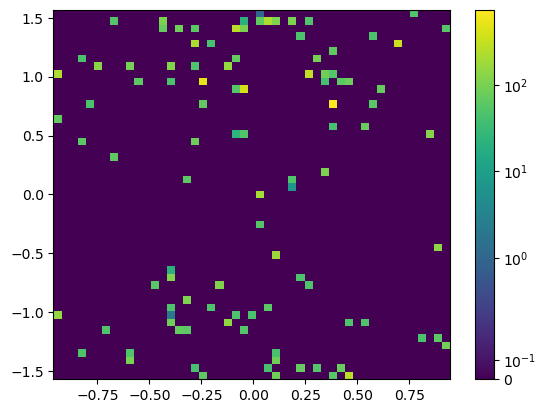

In [55]:
plt.clf()
plt.hist2d(cost1, phi1, bins = [bins1, bins2], norm = SymLogNorm(linthresh=0.5))[0]
plt.colorbar()

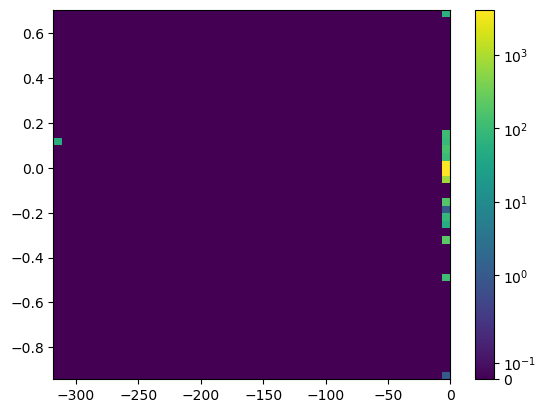

In [56]:

plt.clf()

diff1 = np.sqrt(speed(v)**2 + 2 * grav(0)) - speed(particles)
diff2 = omega1 - omega

bins1 = np.linspace(min(np.min(diff1), np.min(diff1)), max(np.max(diff1), np.max(diff1)), 50)
bins2 = np.linspace(min(np.min(diff2), np.min(diff2)), max(np.max(diff2), np.max(diff2)), 50)
 
vals = plt.hist2d(diff1, diff2, bins = [bins1, bins2], norm= SymLogNorm(linthresh = 0.5))[0]
plt.colorbar()


In [57]:
id = np.argmax(vals[0])
bins1[id], bins2[id]
mask = (diff2<= (bins2[id+1])) * (diff2 >= (bins2[id])) * (diff1 < -300)
particles[mask]

array([[-171.61763346,  254.29520381, -115.64703146],
       [-171.48630091,  254.30680435, -115.87128109],
       [-171.54944056,  254.25923004, -115.64818281],
       [-171.49349579,  254.3424795 , -115.67271405],
       [-171.4846443 ,  254.2023955 , -115.83603358],
       [-171.49131656,  254.22072253, -115.80420022],
       [-171.53009409,  254.40218425, -115.67575685],
       [-171.67169598,  254.38931319, -115.67325185],
       [-171.52090003,  254.22469644, -115.7934991 ],
       [-171.53989954,  254.28219296, -115.92444637],
       [-171.43673264,  254.24765985, -115.59994778],
       [-171.59884078,  254.35872142, -115.93644686],
       [-171.35293179,  254.33230974, -115.77013339],
       [-171.48505176,  254.24608789, -115.67843308],
       [-171.64724838,  254.36753137, -115.87604251],
       [-171.71197759,  254.47779751, -115.7494708 ],
       [-171.58470829,  254.30728385, -115.85494767],
       [-171.60678317,  254.32095335, -115.6437092 ],
       [-171.40141567,  254.

## Get the density enhancement. f_i is normalised to one, but due to density enhancements by the sun, the final distribution is normalised to a little over one.